# Tracers along a Weddell Sea abyssal pathway

We sample potential temperature, salinity, $\sigma_2$, and SF$_6$ every 5 km along a piecewise-linear transect that follows dense, SF$_6$-rich water leaving the Weddell Sea shelf, for every year of both experiments. We also keep bottom SF$_6$ and $\sigma_2$ in the final model year for the maps in Figure 10. Inputs are the yearly CM4X tracers on depth levels.

In [1]:
import sys

import cartopy.crs as ccrs
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xesmf as xe
from pyproj import Geod
from xgcm import Grid

sys.path.insert(0, "../src")
from paths import outputdir
from cm4x import open_cm4x_tracers
from depth import approximate_z_top_down
from plotting import set_style, land_feature

set_style(dpi=150)

section_vars = ["thetao", "so", "sigma2_offline", "sf6"]
spacing_km = 5  # distance between transect samples
depth_target = np.arange(-5500.0, 0.1, 50)  # depths of the section [m]
weddell_lons = (-70, -25)  # longitudes kept for the sampling, well beyond the transect

In [2]:
from dask.distributed import Client
from dask_jobqueue import SLURMCluster

# 3 nodes (36 cores, 190 GB each) to remap and sample 250 years of 3-D tracers
cluster = SLURMCluster(cores=36, processes=1, memory="190GB", walltime="01:00:00",
                       queue="scavenger", log_directory="logs")
cluster.scale(jobs=3)
client = Client(cluster)
client.wait_for_workers(2)

client

<Client: 'tcp://10.151.1.98:38413' processes=0 threads=0, memory=0 B>

In [3]:
ds = open_cm4x_tracers(parallel = False)

## Transect

In [4]:
lat_tie = np.array([-73, -70, -67, -64.5, -63.0, -62.4])
lon_tie = np.array([-55, -54.1, -53.5, -52, -46.5, -41])

_, _, leg_m = Geod(ellps="WGS84").inv(lon_tie[:-1], lat_tie[:-1], lon_tie[1:], lat_tie[1:])
s_tie = np.concatenate([[0], np.cumsum(leg_m) / 1000])  # along-section distance of the tie points [km]

s = np.arange(0, s_tie[-1] + spacing_km, spacing_km)
lon_points = np.interp(s, s_tie, lon_tie)
lat_points = np.interp(s, s_tie, lat_tie)

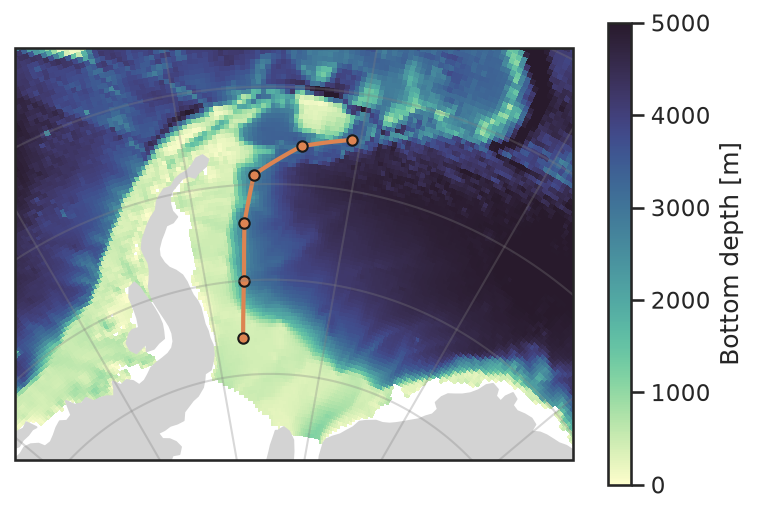

In [5]:
fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={"projection": ccrs.SouthPolarStereo(central_longitude=-50)})
ax.set_extent([-75, -20, -78, -58], ccrs.PlateCarree())
mesh = ax.pcolormesh(ds.geolon, ds.geolat, ds.deptho, cmap=cmo.deep, vmin=0, vmax=5000,
                     shading="auto", rasterized=True, transform=ccrs.PlateCarree())
ax.add_feature(land_feature, zorder=1)
ax.plot(lon_points, lat_points, color="C1", lw=2, transform=ccrs.Geodetic())
ax.plot(lon_tie, lat_tie, "o", color="C1", mec="k", ms=5, transform=ccrs.PlateCarree())
ax.gridlines(color="gray", alpha=0.3)
fig.colorbar(mesh, ax=ax, shrink=0.8, label="Bottom depth [m]")

## Remap to fixed depths

Target depths between the deepest valid value and the seafloor take that deepest value; depths below the seafloor are masked.

In [7]:
in_weddell = (((ds.geolon - weddell_lons[0]) % 360) <= (weddell_lons[1] - weddell_lons[0])).any("yh")
ds_weddell = ds[section_vars + ["thkcello"]].assign_coords(z_i=ds.z_i)  # keep the interfaces, which no variable uses
ds_weddell = ds_weddell.isel(xh=np.flatnonzero(in_weddell.values))
grid = Grid(ds_weddell, coords={"Z": {"center": "z_l"}}, periodic=False, autoparse_metadata=False)

ds_filtered = ds_weddell.where(ds_weddell.thkcello.fillna(0.0) > 0.0)
ds_filtered["depth"] = approximate_z_top_down(ds_weddell, dim="z")
ds_filtered = ds_filtered.chunk({"z_l": -1})

ds_remap = xr.merge([
    grid.transform(ds_filtered[v], "Z", depth_target, target_data=ds_filtered["depth"])
    for v in section_vars
])
ds_remap = ds_remap.chunk({"depth": -1})

in_ocean = -ds_remap["depth"] <= ds_remap["deptho"]
for v in section_vars:
    da = ds_remap[v].where(in_ocean)
    deepest_valid = ds_remap["depth"].where(da.notnull()).min("depth")
    bottom_gap = in_ocean & (ds_remap["depth"] < deepest_valid)
    ds_remap[v] = da.where(~bottom_gap, da.bfill("depth")).where(in_ocean)
ds_remap = ds_remap.reset_coords(names="deptho")

## Sample along the transect

In [8]:
ds_locs = xr.Dataset({
    "lon": xr.DataArray(lon_points, dims="locations"),
    "lat": xr.DataArray(lat_points, dims="locations"),
})
regridder = xe.Regridder(ds_remap, ds_locs, "bilinear", locstream_out=True, periodic=False)
transect = regridder(ds_remap, skipna=True, na_thres=1.0).compute()

In [9]:
transect = transect.assign_coords(
    lat=("locations", lat_points),
    lon=("locations", lon_points),
    transect_length=("locations", s),
)
transect["transect_length"].attrs.update({"long_name": "along-section distance", "units": "km"})
transect = transect.swap_dims({"locations": "transect_length"}).sortby("transect_length")

for v in section_vars:
    transect[v] = transect[v].where(-transect.depth < transect.deptho)

transect["tie_lon"] = ("tie", lon_tie)
transect["tie_lat"] = ("tie", lat_tie)
transect["tie_length"] = ("tie", s_tie)

## Bottom SF$_6$ and $\sigma_2$ in the final year

We hide the shallowest shelf (bottom depth ≤ 100 m), and rename the map coordinates so they do not clash with the transect's.

In [10]:
bottom = ds[["sf6", "sigma2_offline"]].isel(year=-1).ffill("z_l").isel(z_l=-1)  # value in the deepest wet cell
bottom = bottom.where(bottom.deptho > 100).compute()

bottom_maps = xr.Dataset(
    {
        "bottom_sf6": (bottom["sf6"].dims, bottom["sf6"].values),
        "bottom_sigma2": (bottom["sigma2_offline"].dims, bottom["sigma2_offline"].values),
    },
    coords={
        "expt": bottom["expt"].values,
        "map_lon": (bottom["lon"].dims, bottom["lon"].values),
        "map_lat": (bottom["lat"].dims, bottom["lat"].values),
        "map_year": bottom["year"].values,
    },
)

In [11]:
xr.merge([transect, bottom_maps]).to_zarr(outputdir("Weddell_transect_tracers.zarr"), mode="w")

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
